# House Price Prediction using Machine Learning

## Problem Statement

The goal is to predict house prices using features like Overall Quality, Living Area, and Garage Cars.

In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Dataset basic information

print("Rows and Columns:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nData Types:")
print(df.dtypes)

print("\nStatistics:")
df.describe()

Rows and Columns: (1460, 81)

Columns:
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'Garage

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


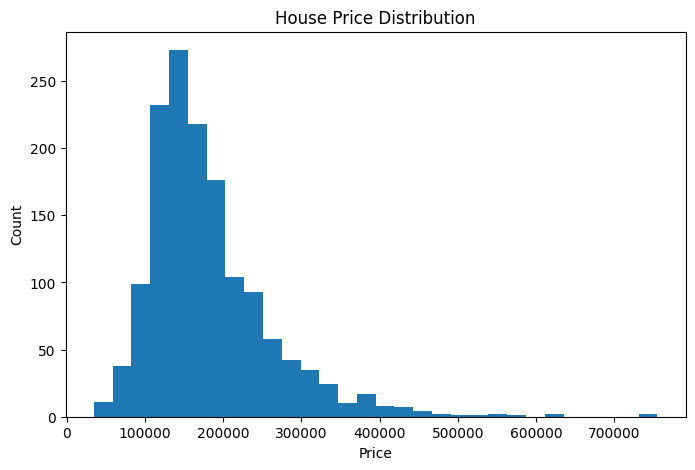

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['SalePrice'], bins=30)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

In [ ]:
print(df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [37]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [35]:
df.drop_duplicates(inplace=True)

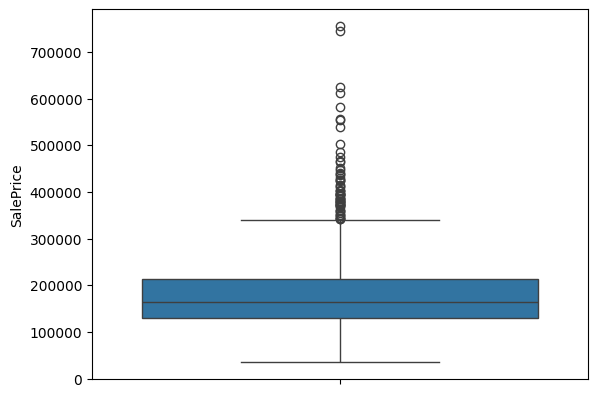

In [38]:
import seaborn as sns

sns.boxplot(df['SalePrice'])
plt.show()

df = df[df['SalePrice'] < df['SalePrice'].quantile(0.99)]

In [ ]:
X = df[['OverallQual', 'GrLivArea', 'GarageCars']]
y = df['SalePrice']

print(X.head())
print(y.head())

   OverallQual  GrLivArea  GarageCars
0            7       1710           2
1            6       1262           2
2            7       1786           2
3            7       1717           3
4            8       2198           3
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[139105.72094361 288283.25743322 132683.55080386 189493.36988067
 289972.24505591  42635.1961445  229962.12619323 179669.84082008
  42635.1961445  127682.49526694]


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 28121.52415174796
R2 Score: 0.7585805446926186


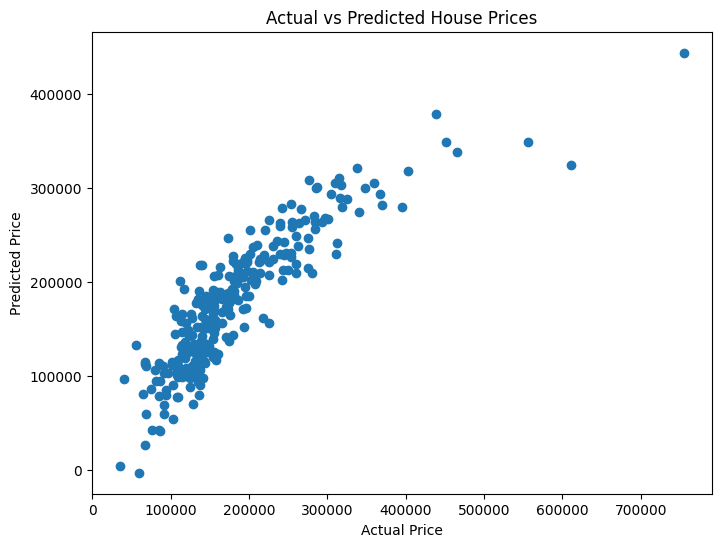

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

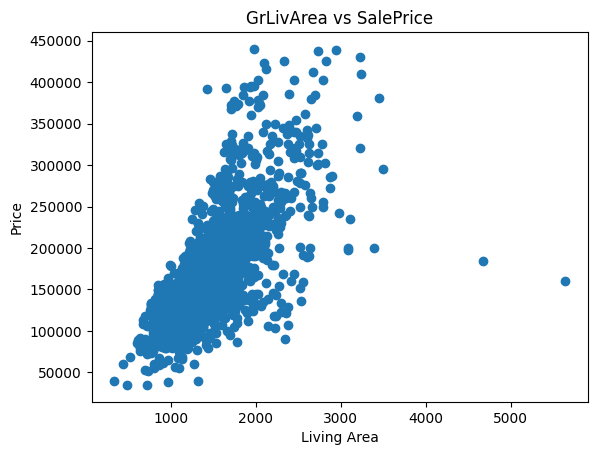

In [39]:
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel("Living Area")
plt.ylabel("Price")
plt.title("GrLivArea vs SalePrice")
plt.show()

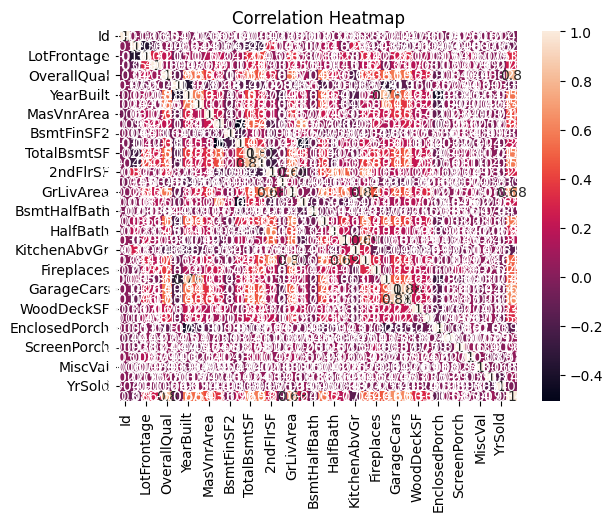

In [41]:
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print("MAE:", mae)
print("R2:", r2)

MAE: 28121.52415174796
R2: 0.7585805446926186


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features
X = df[['OverallQual', 'GrLivArea', 'GarageCars']]

# Target
y = df['SalePrice']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [43]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, name):
    pred = model.predict(X_test)
    print(name)
    print("MAE:", mean_absolute_error(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("R2:", r2_score(y_test, pred))
    print("----------------")

evaluate(model, "Linear Regression")
evaluate(rf, "Random Forest")
evaluate(xgb, "XGBoost")

Linear Regression
MAE: 28121.52415174796
RMSE: 43032.150480414624
R2: 0.7585805446926186
----------------
Random Forest
MAE: 24092.27987137472
RMSE: 35265.2212419196
R2: 0.8378640235566193
----------------
XGBoost
MAE: 24176.2578125
RMSE: 37913.523497559545
R2: 0.8125978708267212
----------------


In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")

print(
df.isnull().sum()
)

Dataset Shape:
(1460, 81)

Missing Values:
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [ ]:
df_clean = df.copy()

for col in df_clean.columns:

    if df_clean[col].dtype=="object":

        df_clean[col].fillna(
            df_clean[col].mode()[0],
            inplace=True
        )

    else:

        df_clean[col].fillna(
            df_clean[col].median(),
            inplace=True
        )

print("Original Shape:")
print(df.shape)

print()

print("After Cleaning:")
print(df_clean.shape)

print()

print(
df_clean.isnull().sum().sum()
)

Original Shape:
(1460, 81)

After Cleaning:
(1460, 81)

0


/tmp/ipykernel_4820/99696706.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(
/tmp/ipykernel_4820/99696706.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value},

In [ ]:
features = [

'OverallQual',

'GrLivArea',

'GarageCars'

]

target='SalePrice'

X=df_clean[features]

y=df_clean[target]

print(
"Selected Features:"
)

print(
X.head()
)

print()

print(
"Target:"
)

print(
y.head()
)

Selected Features:
   OverallQual  GrLivArea  GarageCars
0            7       1710           2
1            6       1262           2
2            7       1786           2
3            7       1717           3
4            8       2198           3

Target:
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression


X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)


model=LinearRegression()

model.fit(
X_train,
y_train
)

print(
"Model Trained Successfully"
)

Model Trained Successfully


In [ ]:
from sklearn.metrics import (
mean_absolute_error,
r2_score
)

pred = model.predict(
X_test
)

mae = mean_absolute_error(
y_test,
pred
)

r2 = r2_score(
y_test,
pred
)

print(
"MAE:",
mae
)

print(
"R2 Score:",
r2
)

MAE: 28121.52415174796
R2 Score: 0.7585805446926186


In [ ]:
import pickle

with open(
"model.pkl",
"wb"
) as f:

    pickle.dump(
        model,
        f
    )

print(
"model.pkl saved"
)

model.pkl saved


# New Section

This model predicts house prices with reasonable accuracy using basic regression techniques. The R² score shows the model explains around 75% variance in data.